# 🧠 Giai đoạn 1: Nghiên cứu MTCNN + FaceNet
## Nhận diện khuôn mặt & Tìm ngưỡng (Threshold Research)

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
DVT_PATH = '/content/drive/MyDrive/MTCNN&FaceNet/dvt'
print('Files in dvt:', os.listdir(DVT_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in dvt: ['1.jpg', '2.jpg', '3.jpg', '4.jpg']


In [ ]:
!pip uninstall -y Pillow
!pip install Pillow

Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 98.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 12.2.0 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [ ]:
# ========================================
# BƯỚC 1: Cài đặt thư viện
# ========================================
!pip install facenet-pytorch opencv-python-headless -q
print('✅ Cài đặt hoàn tất!')

✅ Cài đặt hoàn tất!


In [ ]:
# Import tất cả thư viện cần thiết
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1

# Chọn device (GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Đang dùng: {device}')

# Khởi tạo MTCNN (phát hiện & cắt khuôn mặt)
mtcnn = MTCNN(
    image_size=160,    # FaceNet cần ảnh 160x160
    margin=20,         # Lề xung quanh khuôn mặt
    min_face_size=40,  # Kích thước mặt tối thiểu
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=True,
    device=device
)
 
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print('✅ Mô hình đã sẵn sàng!')

🖥️  Đang dùng: cuda


  0%|          | 0.00/107M [00:00<?, ?B/s]

✅ Mô hình đã sẵn sàng!


=== 📸 ĐĂNG KÝ: ảnh 1 (ảnh chính diện) ===


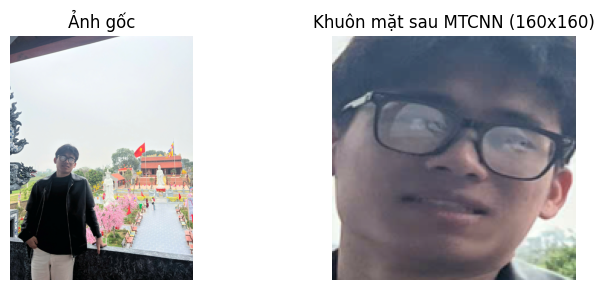

✅ Vector shape: (512,)
📊 5 giá trị đầu tiên: [ 0.0096 -0.033  -0.0445  0.0864  0.005 ]
📏 L2 Norm của vector: 1.0000 (≈1.0 là chuẩn)


In [ ]:
# ========================================
# BƯỚC 2: Hàm tạo "Vân tay khuôn mặt"
# ========================================

def get_face_embedding(image_path, show=True):
    """
    Nhận đường dẫn ảnh, trả về vector embedding 512 chiều.
    Returns: (embedding_vector, face_tensor) hoặc (None, None) nếu không tìm thấy mặt.
    """
    # 1. Đọc ảnh bằng PIL (facenet_pytorch yêu cầu PIL)
    img_pil = Image.open(image_path).convert('RGB')

    # 2. MTCNN phát hiện và cắt khuôn mặt → tensor 3x160x160
    face_tensor = mtcnn(img_pil)

    if face_tensor is None:
        print(f'❌ Không tìm thấy khuôn mặt trong: {image_path}')
        return None, None

    # 3. Hiển thị khuôn mặt đã cắt
    if show:
        face_np = face_tensor.permute(1, 2, 0).numpy()
        face_np = (face_np - face_np.min()) / (face_np.max() - face_np.min())
        fig, axes = plt.subplots(1, 2, figsize=(8, 3))
        axes[0].imshow(img_pil)
        axes[0].set_title('Ảnh gốc')
        axes[0].axis('off')
        axes[1].imshow(face_np)
        axes[1].set_title('Khuôn mặt sau MTCNN (160x160)')
        axes[1].axis('off')
        plt.tight_layout()
        plt.show()

    # 4. FaceNet tạo vector embedding
    with torch.no_grad():
        face_batch = face_tensor.unsqueeze(0).to(device)  # (1, 3, 160, 160)
        embedding = facenet(face_batch)
        embedding = embedding.cpu().numpy().flatten()      # (512,)

    return embedding, face_tensor


# --- Đăng ký: Ảnh chính diện của bạn (ảnh 1) ---
print('=== 📸 ĐĂNG KÝ: ảnh 1 (ảnh chính diện) ===')
emb_1, _ = get_face_embedding(f'{DVT_PATH}/1.jpg')

if emb_1 is not None:
    print(f'✅ Vector shape: {emb_1.shape}')
    print(f'📊 5 giá trị đầu tiên: {emb_1[:5].round(4)}')
    print(f'📏 L2 Norm của vector: {np.linalg.norm(emb_1):.4f} (≈1.0 là chuẩn)')  # FaceNet normalize về unit sphere

=== 📸 Ảnh 2 (ảnh khác của BẠN) ===


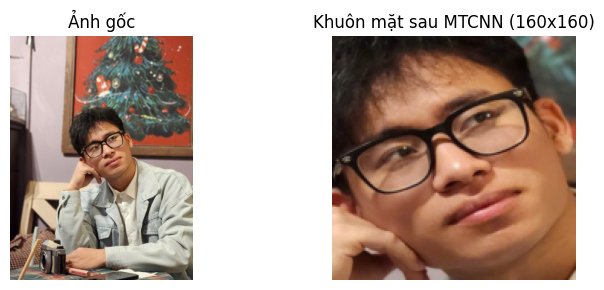


=== 📸 Ảnh 4 (ảnh NGƯỜI KHÁC) ===


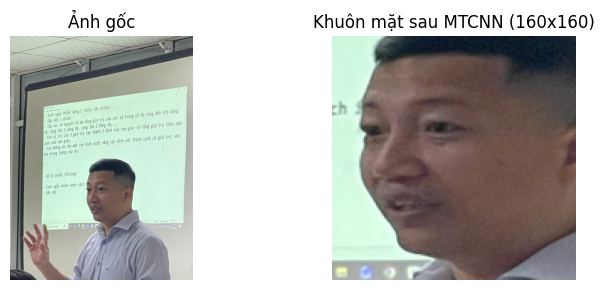


📊 KẾT QUẢ SO SÁNH
  Ảnh 1 vs Ảnh 2 (CÙNG người):
    Euclidean distance : 0.7916
    Cosine similarity  : 0.6867
  Ảnh 1 vs Ảnh 4 (KHÁC người):
    Euclidean distance : 1.2506
    Cosine similarity  : 0.2180

💡 GỢI Ý NGƯỠNG (threshold) = 1.02
   → Khoảng cách < 1.02 : CÙNG người ✅
   → Khoảng cách > 1.02 : NGƯỜI LẠ  ❌

⚠️  LƯU Ý: Ngưỡng phổ biến với VGGFace2 là 0.8 - 1.1
   Hãy điều chỉnh dựa trên kết quả thực tế của bạn!


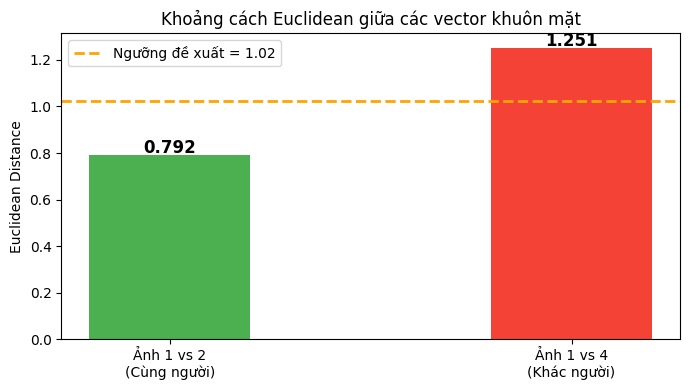

In [ ]:
# ========================================
# BƯỚC 3: Nghiên cứu ngưỡng sai số
# ========================================
def euclidean_distance(emb_a, emb_b):
    """Tính khoảng cách Euclidean giữa 2 vector."""
    return np.linalg.norm(emb_a - emb_b)

def cosine_similarity(emb_a, emb_b):
    """Tính độ tương đồng Cosine (1 = giống hệt, 0 = khác hoàn toàn)."""
    return np.dot(emb_a, emb_b) / (np.linalg.norm(emb_a) * np.linalg.norm(emb_b))

# Tải 2 ảnh so sánh
print('=== 📸 Ảnh 2 (ảnh khác của BẠN) ===')
emb_2, _ = get_face_embedding(f'{DVT_PATH}/2.jpg')

print('\n=== 📸 Ảnh 4 (ảnh NGƯỜI KHÁC) ===')
emb_4, _ = get_face_embedding(f'{DVT_PATH}/4.jpg')

# --- Tính toán khoảng cách ---
if all(e is not None for e in [emb_1, emb_2, emb_4]):
    dist_same   = euclidean_distance(emb_1, emb_2)  # Cùng người
    dist_diff   = euclidean_distance(emb_1, emb_4)  # Khác người
    cos_same    = cosine_similarity(emb_1, emb_2)
    cos_diff    = cosine_similarity(emb_1, emb_4)

    print('\n' + '='*55)
    print('📊 KẾT QUẢ SO SÁNH')
    print('='*55)
    print(f'  Ảnh 1 vs Ảnh 2 (CÙNG người):')
    print(f'    Euclidean distance : {dist_same:.4f}')
    print(f'    Cosine similarity  : {cos_same:.4f}')
    print(f'  Ảnh 1 vs Ảnh 4 (KHÁC người):')
    print(f'    Euclidean distance : {dist_diff:.4f}')
    print(f'    Cosine similarity  : {cos_diff:.4f}')
    print('='*55)

    # Gợi ý ngưỡng dựa trên dữ liệu thực tế
    suggested_threshold = (dist_same + dist_diff) / 2
    print(f'\n💡 GỢI Ý NGƯỠNG (threshold) = {suggested_threshold:.2f}')
    print(f'   → Khoảng cách < {suggested_threshold:.2f} : CÙNG người ✅')
    print(f'   → Khoảng cách > {suggested_threshold:.2f} : NGƯỜI LẠ  ❌')
    print(f'\n⚠️  LƯU Ý: Ngưỡng phổ biến với VGGFace2 là 0.8 - 1.1')
    print(f'   Hãy điều chỉnh dựa trên kết quả thực tế của bạn!')

    # Visualization
    labels = ['Ảnh 1 vs 2\n(Cùng người)', 'Ảnh 1 vs 4\n(Khác người)']
    distances = [dist_same, dist_diff]
    colors = ['#4CAF50', '#F44336']

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels, distances, color=colors, width=0.4)
    plt.axhline(y=suggested_threshold, color='orange', linestyle='--',
                linewidth=2, label=f'Ngưỡng đề xuất = {suggested_threshold:.2f}')
    plt.ylabel('Euclidean Distance')
    plt.title('Khoảng cách Euclidean giữa các vector khuôn mặt')
    plt.legend()
    for bar, val in zip(bars, distances):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ========================================
# LƯU KẾT QUẢ để dùng ở các giai đoạn sau
# ========================================
import json
THRESHOLD = float(input('Nhập ngưỡng bạn chọn (mặc định 0.9): ') or 0.9)

research_results = {
    'threshold': THRESHOLD,
    'dist_same_person': round(float(dist_same), 4),
    'dist_diff_person': round(float(dist_diff), 4),
    'note': 'Khoảng cách Euclidean < threshold → cùng người'
}

result_path = '/content/drive/MyDrive/MTCNN&FaceNet/threshold_research.json'
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(research_results, f, ensure_ascii=False, indent=2)

print(f'✅ Đã lưu kết quả nghiên cứu vào: {result_path}')
print(json.dumps(research_results, indent=2, ensure_ascii=False))

Nhập ngưỡng bạn chọn (mặc định 0.9): 1
✅ Đã lưu kết quả nghiên cứu vào: /content/drive/MyDrive/MTCNN&FaceNet/threshold_research.json
{
  "threshold": 1.0,
  "dist_same_person": 0.7916,
  "dist_diff_person": 1.2506,
  "note": "Khoảng cách Euclidean < threshold → cùng người"
}
